# Lecture 03 Back Testing

In [88]:
# Cell 1: Imports
import pandas as pd
import numpy as np
import yfinance as yf
from datetime import datetime
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error
import statsmodels.api as sm

In [89]:
# Cell 2: Download data and prepare features
start_date = datetime(2020, 1, 1)
end_date = datetime(2023, 12, 31)

# fetch target variable
stock_symbol = 'PANW'
stock = yf.download(stock_symbol, start_date, end_date)

# prepare macro-finance features
feature_macro = pd.read_csv('INFO6105_FeatureMart.csv')
feature_macro['Date'] = pd.to_datetime(feature_macro['Date'])
feature_macro.set_index('Date', inplace=True)

# Ensure all date indexes match market dates
common_dates = stock.index.intersection(feature_macro.index)
stock = stock.loc[common_dates]
features = feature_macro.loc[common_dates]

# Fill missing values
features = features.fillna(method='ffill').fillna(method='bfill')

# Print data information
print("Stock data shape:", stock.shape)
print("Features data shape:", features.shape)
print("\nNaN values in features:", features.isna().sum().sum())
print("NaN values in stock data:", stock.isna().sum().sum())

[*********************100%***********************]  1 of 1 completed

Stock data shape: (1006, 6)
Features data shape: (1006, 28)

NaN values in features: 0
NaN values in stock data: 0



/var/folders/p3/rcvq04y148z9r_2p528s4znc0000gn/T/ipykernel_10448/3131530545.py:20: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  features = features.fillna(method='ffill').fillna(method='bfill')


In [90]:
# Cell 3: Define backtesting function (updated NaN handling)
def run_backtest(stock_data, features, model_name, win, start_date):
    try:
        # Convert start_date to Timestamp if string
        if isinstance(start_date, str):
            start_date = pd.Timestamp(start_date)
        
        # Find the first valid date after start_date
        valid_dates = stock_data.index[stock_data.index >= start_date]
        if len(valid_dates) == 0:
            raise ValueError("Start date is after all available data")
        start_date = valid_dates[0]
        
        # Initialize variables
        train_start = stock_data.index.get_loc(start_date)
        position = 100
        
        y_pred = {}
        y_test = {}
        signal = {}
        gain_loss = {}
        balance = {train_start: stock_data['Close'].iloc[train_start]*position}
        
        # Run backtest
        for t in range(train_start, len(stock_data)-1):
            if t < win:
                continue
            
            # Prepare training data
            X_train = features.iloc[t-win:t]
            y_train = stock_data['Close'].iloc[t-win:t]
            X_test = features.iloc[t:t+1]
            
            # Check for NaN values
            if X_train.isna().any().any() or y_train.isna().any():
                continue
            
            try:
                # Fit model and make prediction
                if model_name == 'OLS':
                    model = sm.OLS(y_train, X_train).fit()
                    pred = float(model.predict(X_test).iloc[0])
                elif model_name == 'RandomForest':
                    model = RandomForestRegressor(n_estimators=100, random_state=42)
                    model.fit(X_train, y_train.values)
                    pred = float(model.predict(X_test.values)[0])
                else:  # XGBoost
                    model = XGBRegressor(n_estimators=100, random_state=42)
                    model.fit(X_train, y_train.values)
                    pred = float(model.predict(X_test.values)[0])
                
                # Only store results if prediction is valid
                if not np.isnan(pred):
                    y_pred[t] = pred
                    y_test[t] = stock_data['Open'].iloc[t]
                    
                    if pred >= stock_data['Open'].iloc[t]:
                        signal[t] = 1
                        gain_loss[t] = -position * stock_data['Open'].iloc[t] + position * stock_data['Close'].iloc[t]
                    else:
                        signal[t] = -1
                        gain_loss[t] = position * stock_data['Open'].iloc[t] - position * stock_data['Close'].iloc[t]
                    
                    balance[t+1] = balance[t] + gain_loss[t]
                
            except Exception as e:
                print(f"Error in iteration {t}: {str(e)}")
                continue
        
        # Create results DataFrame
        if len(balance) > 1:  # Check if we have any trading results
            results = pd.DataFrame({
                'signal': signal,
                'gain_loss': gain_loss,
                'balance': balance,
                'y_pred': y_pred,
                'y_test': y_test
            })
            results.index = stock_data.index[list(results.index)]
            
            # Drop any remaining NaN values
            results = results.dropna()
            
            if not results.empty:
                return results
        
        raise ValueError("No valid trading results generated")
        
    except Exception as e:
        print(f"Error in backtest: {str(e)}")
        return pd.DataFrame()

In [91]:
# Cell 4: Run models with different configurations (updated)
MODELS = ['OLS', 'RandomForest', 'XGBoost']
windows = [30, 60, 90]
start_dates = ['2020-01-01', '2023-04-03']

all_results = []

for model_name in MODELS:
    for win in windows:
        for start in start_dates:
            print(f"\nTesting {model_name} with window={win}, start_date={start}")
            
            results = run_backtest(stock, features, model_name, win, start)
            
            if not results.empty:
                try:
                    # Remove any NaN values before calculating metrics
                    results_clean = results.dropna()
                    
                    if not results_clean.empty:
                        # Calculate performance metrics
                        total_pnl = results_clean['gain_loss'].sum()
                        holding_return = (results_clean['balance'].iloc[-1] - results_clean['balance'].iloc[0]) / results_clean['balance'].iloc[0]
                        rmse = np.sqrt(mean_squared_error(results_clean['y_test'], results_clean['y_pred']))
                        
                        all_results.append({
                            'Model': model_name,
                            'Window': win,
                            'Start_Date': start,
                            'Total_PnL': total_pnl,
                            'Return': holding_return,
                            'RMSE': rmse
                        })
                        
                        print(f"Successfully processed. Return: {holding_return:.2%}")
                    else:
                        print("No valid results after removing NaN values")
                except Exception as e:
                    print(f"Error calculating metrics: {str(e)}")


Testing OLS with window=30, start_date=2020-01-01
Error in iteration 30: 30
Error in iteration 31: 31
Error in iteration 32: 32
Error in iteration 33: 33
Error in iteration 34: 34
Error in iteration 35: 35
Error in iteration 36: 36
Error in iteration 37: 37
Error in iteration 38: 38
Error in iteration 39: 39
Error in iteration 40: 40
Error in iteration 41: 41
Error in iteration 42: 42
Error in iteration 43: 43
Error in iteration 44: 44
Error in iteration 45: 45
Error in iteration 46: 46
Error in iteration 47: 47
Error in iteration 48: 48
Error in iteration 49: 49
Error in iteration 50: 50
Error in iteration 51: 51
Error in iteration 52: 52
Error in iteration 53: 53
Error in iteration 54: 54
Error in iteration 55: 55
Error in iteration 56: 56
Error in iteration 57: 57
Error in iteration 58: 58
Error in iteration 59: 59
Error in iteration 60: 60
Error in iteration 61: 61
Error in iteration 62: 62
Error in iteration 63: 63
Error in iteration 64: 64
Error in iteration 65: 65
Error in iter

/opt/homebrew/anaconda3/lib/python3.12/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
/opt/homebrew/anaconda3/lib/python3.12/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
/opt/homebrew/anaconda3/lib/python3.12/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
/opt/homebrew/anaconda3/lib/python3.12/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
/opt/homebrew/anaconda3/lib/python3.12/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


Error in iteration 34: 34
Error in iteration 35: 35
Error in iteration 36: 36
Error in iteration 37: 37
Error in iteration 38: 38


/opt/homebrew/anaconda3/lib/python3.12/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
/opt/homebrew/anaconda3/lib/python3.12/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
/opt/homebrew/anaconda3/lib/python3.12/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
/opt/homebrew/anaconda3/lib/python3.12/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
/opt/homebrew/anaconda3/lib/python3.12/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


Error in iteration 39: 39
Error in iteration 40: 40
Error in iteration 41: 41
Error in iteration 42: 42
Error in iteration 43: 43


...

Error in iteration 1001: 1001
Error in iteration 1002: 1002
Error in iteration 1003: 1003


/opt/homebrew/anaconda3/lib/python3.12/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
/opt/homebrew/anaconda3/lib/python3.12/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
/opt/homebrew/anaconda3/lib/python3.12/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


Error in iteration 1004: 1004
Error in backtest: No valid trading results generated

Testing RandomForest with window=90, start_date=2023-04-03


/opt/homebrew/anaconda3/lib/python3.12/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
/opt/homebrew/anaconda3/lib/python3.12/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
/opt/homebrew/anaconda3/lib/python3.12/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
/opt/homebrew/anaconda3/lib/python3.12/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
/opt/homebrew/anaconda3/lib/python3.12/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
/opt/homebrew/a

Successfully processed. Return: -12.37%

Testing XGBoost with window=30, start_date=2020-01-01
Error in iteration 30: 30
Error in iteration 31: 31
Error in iteration 32: 32
Error in iteration 33: 33
Error in iteration 34: 34
Error in iteration 35: 35
Error in iteration 36: 36
Error in iteration 37: 37
Error in iteration 38: 38
Error in iteration 39: 39
Error in iteration 40: 40
Error in iteration 41: 41
Error in iteration 42: 42
Error in iteration 43: 43
Error in iteration 44: 44
Error in iteration 45: 45
Error in iteration 46: 46
Error in iteration 47: 47
Error in iteration 48: 48
Error in iteration 49: 49
Error in iteration 50: 50
Error in iteration 51: 51
Error in iteration 52: 52
Error in iteration 53: 53
Error in iteration 54: 54
Error in iteration 55: 55
Error in iteration 56: 56
Error in iteration 57: 57
Error in iteration 58: 58
Error in iteration 59: 59
Error in iteration 60: 60
Error in iteration 61: 61
Error in iteration 62: 62
Error in iteration 63: 63
Error in iteration 64


Model Comparison:
          Model  Window  Start_Date     Total_PnL    Return       RMSE
0           OLS      30  2023-04-03   6432.986450  0.334793  23.108975
1           OLS      60  2023-04-03   9188.992310  0.475169   8.616195
2           OLS      90  2023-04-03  14802.993774  0.761116   8.136134
3  RandomForest      30  2023-04-03   -198.999023 -0.003005   7.499333
4  RandomForest      60  2023-04-03  -5228.997803 -0.259206   9.018168
5  RandomForest      90  2023-04-03  -2568.997192 -0.123720   9.142740
6       XGBoost      30  2023-04-03  -3590.988159 -0.175775   8.667503
7       XGBoost      60  2023-04-03  -3032.998657 -0.147354   9.172790
8       XGBoost      90  2023-04-03   4147.000122  0.218357   9.567974


/opt/homebrew/anaconda3/lib/python3.12/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
/opt/homebrew/anaconda3/lib/python3.12/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
/opt/homebrew/anaconda3/lib/python3.12/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
/opt/homebrew/anaconda3/lib/python3.12/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
/opt/homebrew/anaconda3/lib/python3.12/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
/opt/homebrew/a

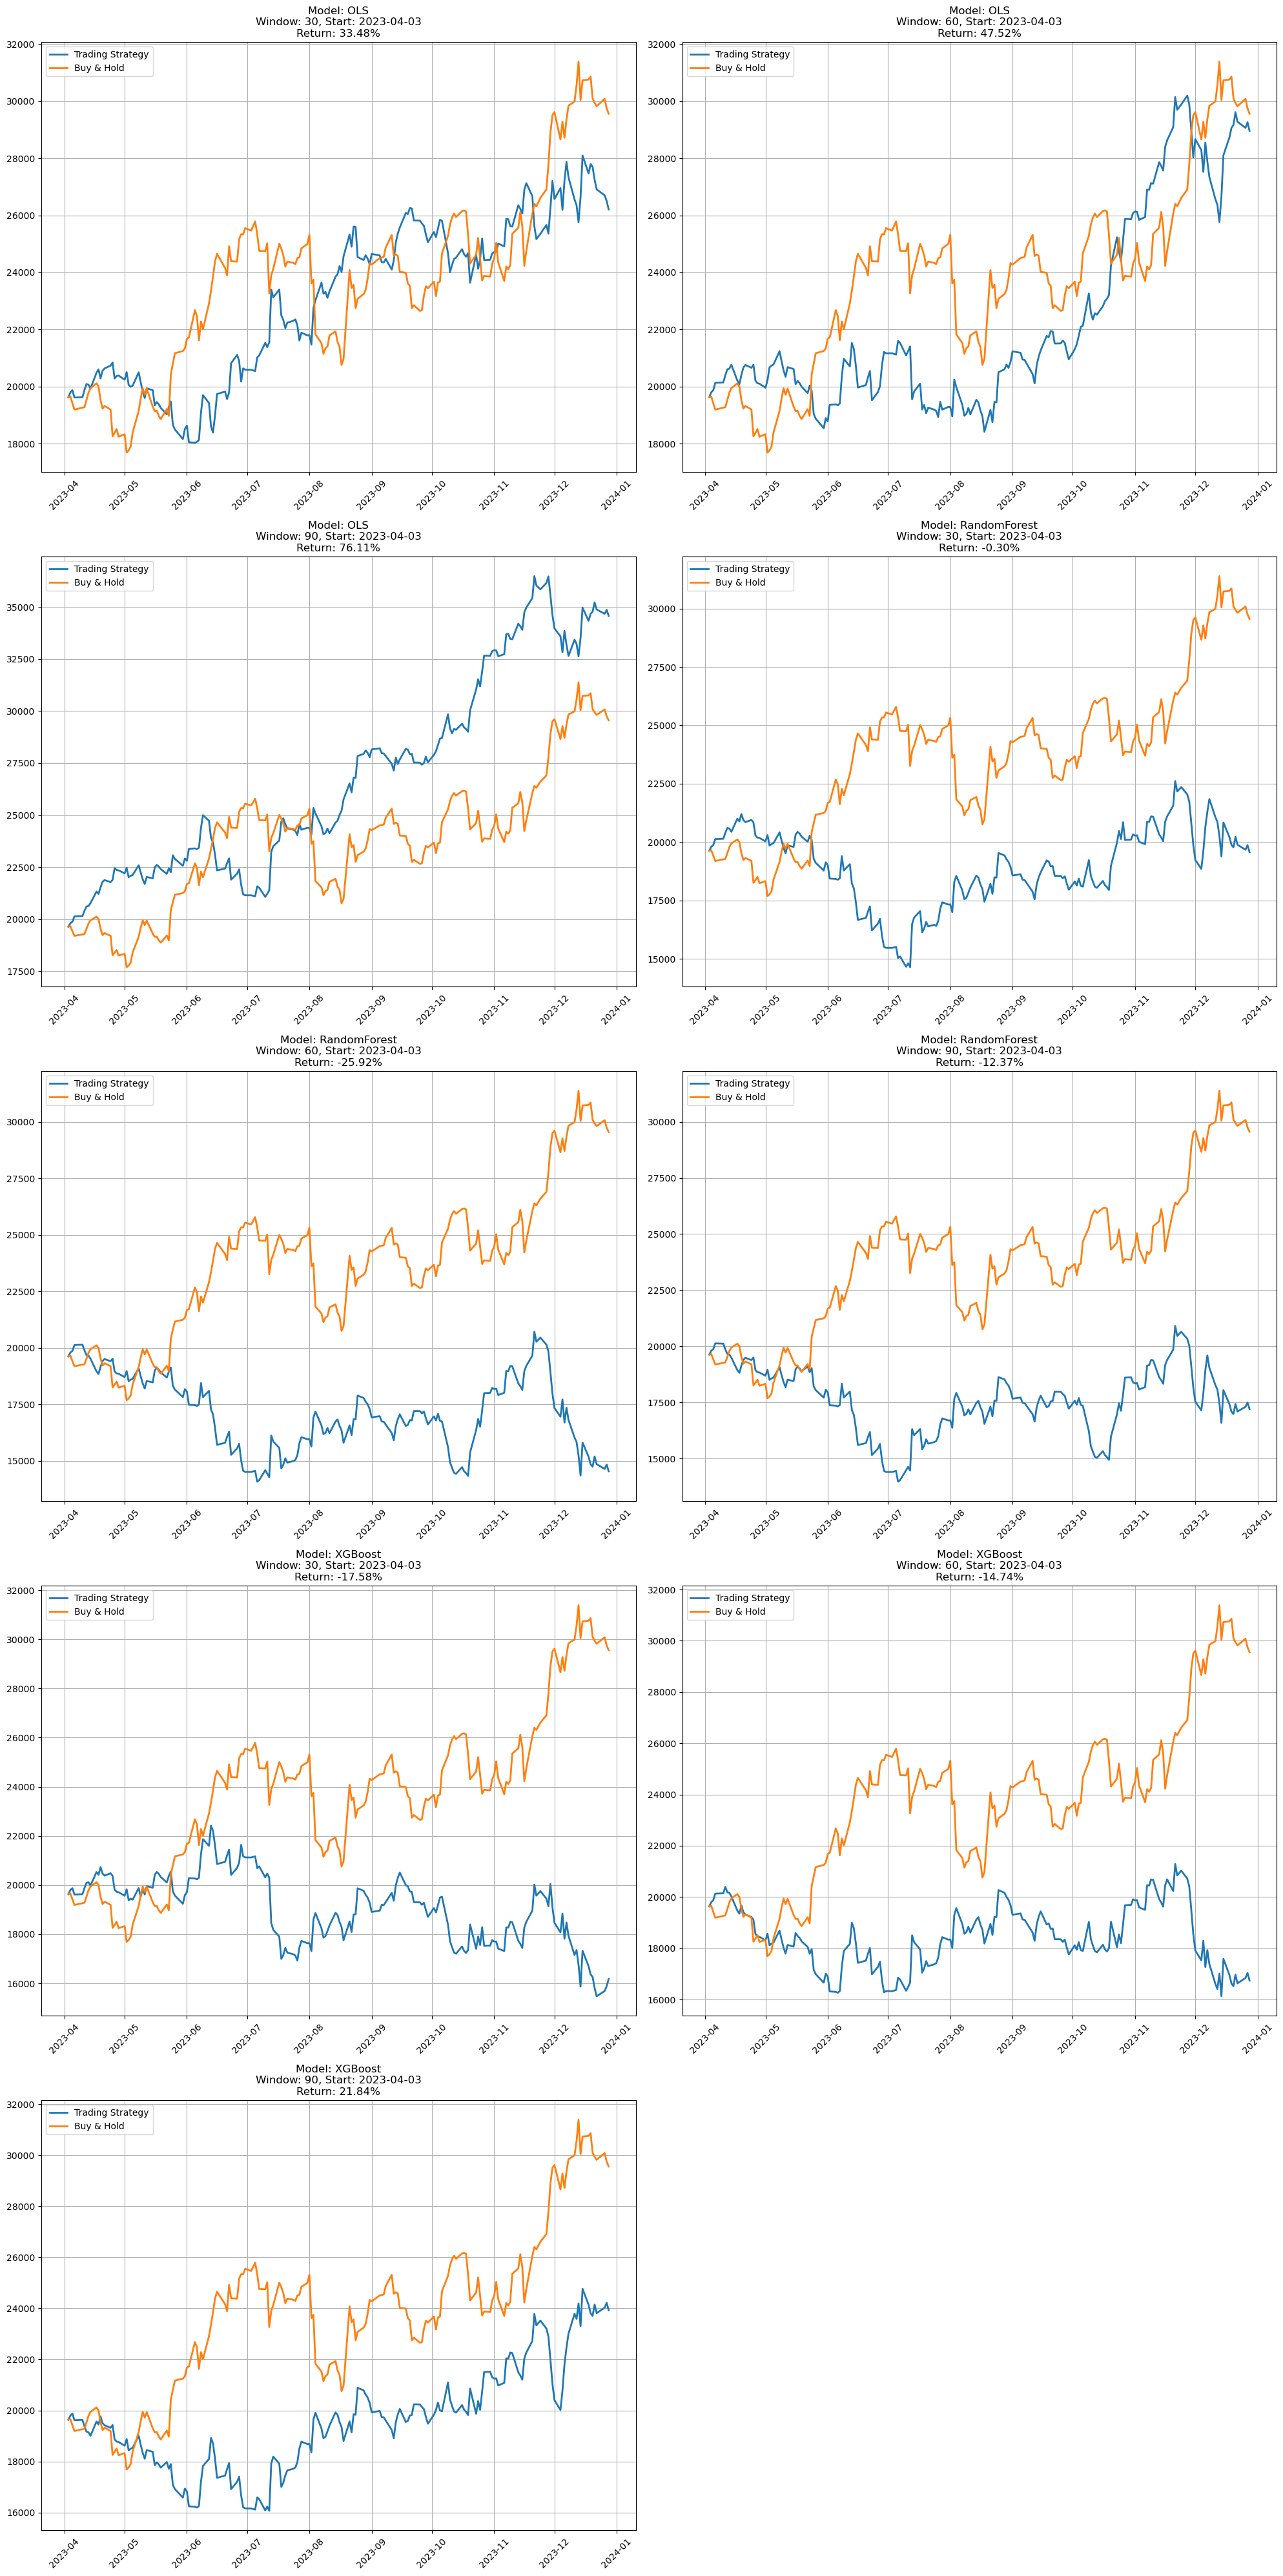


Performance Comparison:
                          RMSE     Return
Start_Date          2023-04-03 2023-04-03
Model        Window                      
OLS          30      23.108975   0.334793
             60       8.616195   0.475169
             90       8.136134   0.761116
RandomForest 30       7.499333  -0.003005
             60       9.018168  -0.259206
             90       9.142740  -0.123720
XGBoost      30       8.667503  -0.175775
             60       9.172790  -0.147354
             90       9.567974   0.218357

Best Configuration:
Model: OLS
Window: 90
Start Date: 2023-04-03
Return: 76.11%
RMSE: 8.14
Total PnL: $14802.99


In [92]:
# Cell 5: Compare results and plot graphs
if all_results:
    # Create comparison DataFrame
    comparison_df = pd.DataFrame(all_results)
    print("\nModel Comparison:")
    print(comparison_df)
    
    # Calculate number of rows and columns needed for subplots
    n_plots = len(comparison_df)
    n_cols = 2  # We'll use 2 columns
    n_rows = (n_plots + 1) // 2  # Calculate rows needed
    
    # Create figure
    plt.figure(figsize=(20, 8*n_rows))
    
    # Plot for each model configuration
    for i, (_, config) in enumerate(comparison_df.iterrows(), 1):
        plt.subplot(n_rows, n_cols, i)
        
        results = run_backtest(
            stock,
            features,
            config['Model'],
            config['Window'],
            config['Start_Date']
        )
        
        if not results.empty:
            # Plot trading strategy
            plt.plot(results['balance'], label='Trading Strategy', linewidth=2)
            
            # Plot buy & hold strategy
            plt.plot(results.index, stock['Close'].loc[results.index] * 100, 
                    label='Buy & Hold', linewidth=2)
            
            plt.title(f"Model: {config['Model']}\nWindow: {config['Window']}, Start: {config['Start_Date']}\nReturn: {config['Return']:.2%}")
            plt.legend()
            plt.grid(True)
            plt.xticks(rotation=45)
    
    plt.tight_layout()
    plt.show()
    
    # Print performance comparison
    print("\nPerformance Comparison:")
    performance_df = comparison_df.pivot_table(
        index=['Model', 'Window'],
        columns='Start_Date',
        values=['Return', 'RMSE']
    )
    print(performance_df)
    
    # Find and print best performing configuration
    best_config = comparison_df.loc[comparison_df['Return'].idxmax()]
    print("\nBest Configuration:")
    print(f"Model: {best_config['Model']}")
    print(f"Window: {best_config['Window']}")
    print(f"Start Date: {best_config['Start_Date']}")
    print(f"Return: {best_config['Return']:.2%}")
    print(f"RMSE: {best_config['RMSE']:.2f}")
    print(f"Total PnL: ${best_config['Total_PnL']:.2f}")

else:
    print("No results were generated. Check for errors in the model execution.")

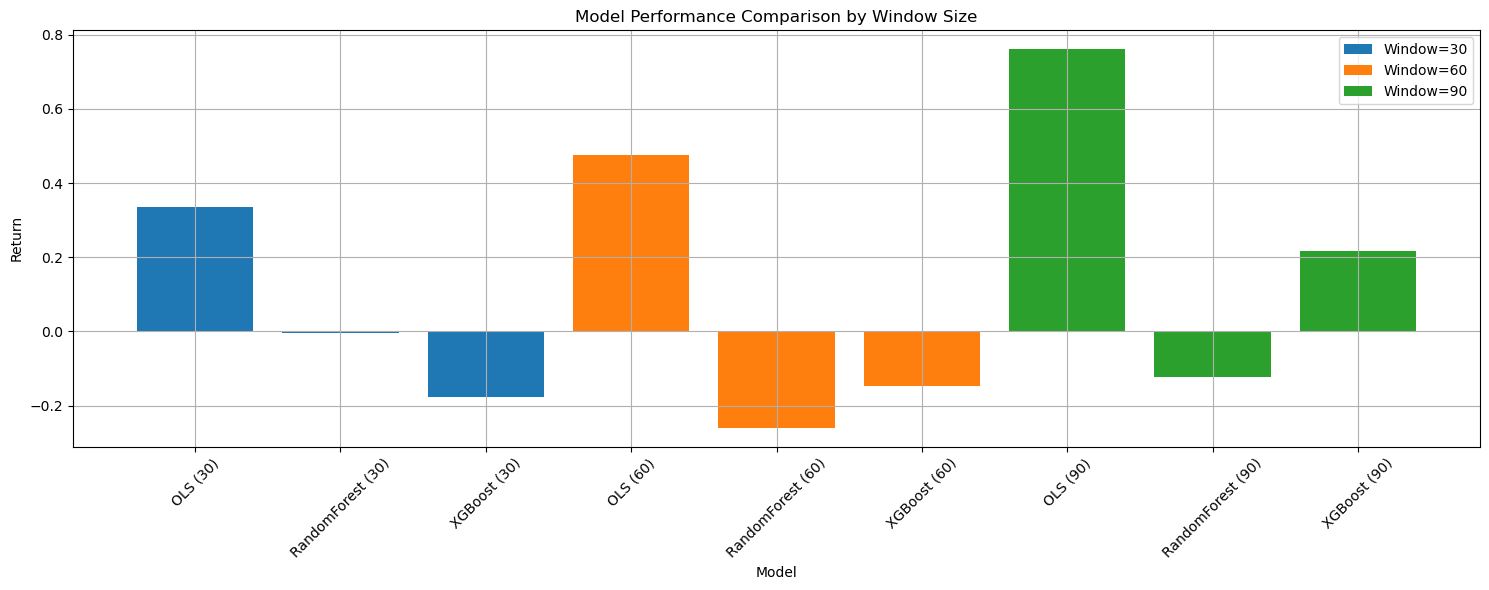

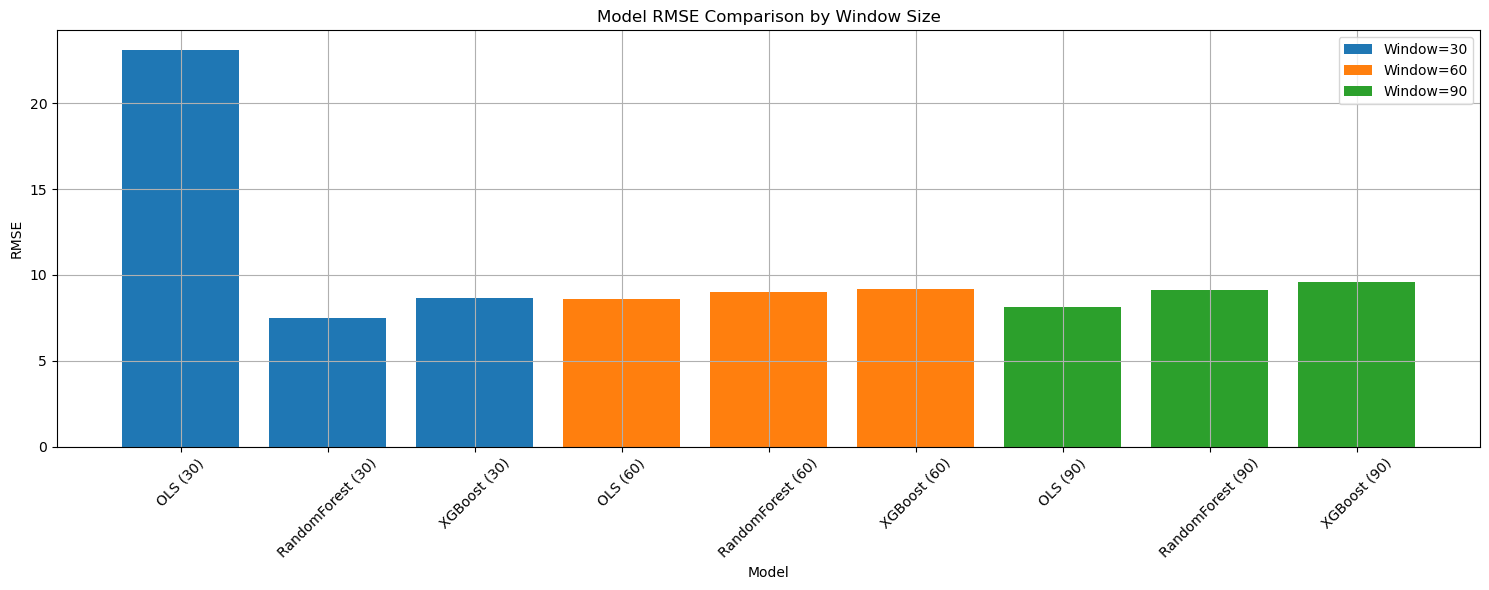

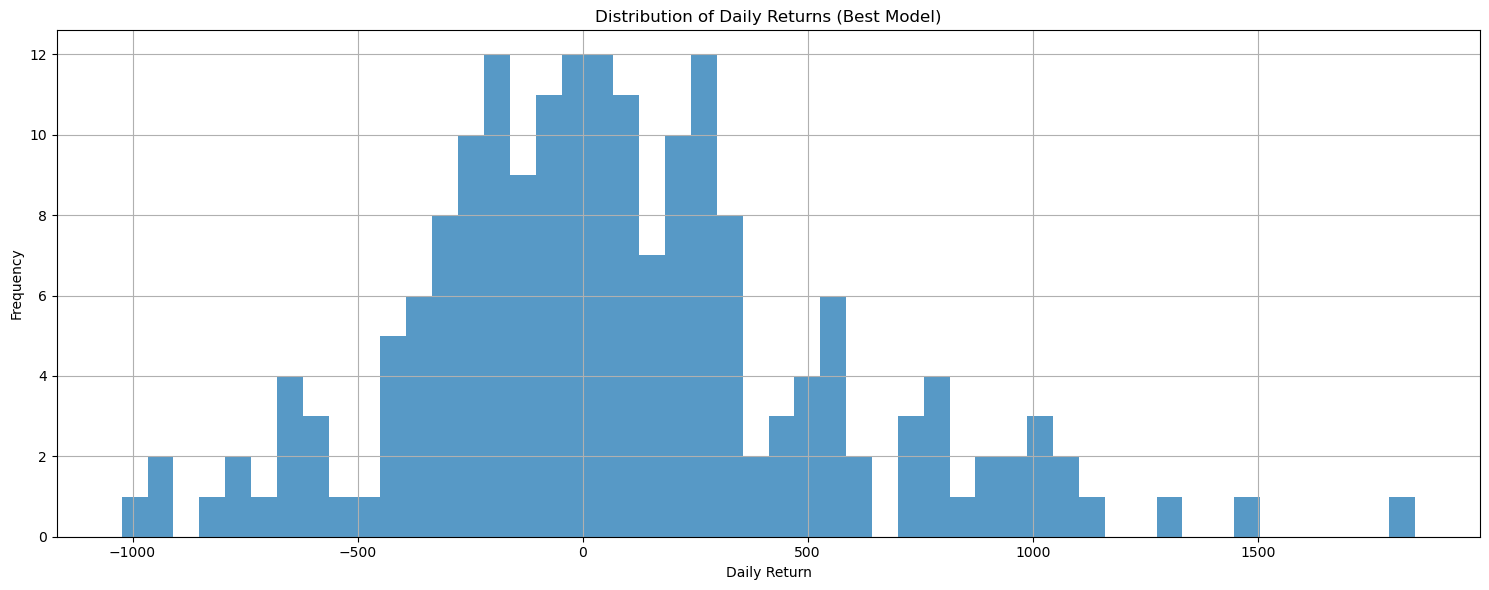

In [93]:
# Cell 6: Additional visualizations
if all_results:
    # Performance comparison bar plot
    plt.figure(figsize=(15, 6))
    for window in comparison_df['Window'].unique():
        mask = comparison_df['Window'] == window
        plt.bar(comparison_df[mask]['Model'] + f' ({window})', 
               comparison_df[mask]['Return'], 
               label=f'Window={window}')
    plt.title('Model Performance Comparison by Window Size')
    plt.xlabel('Model')
    plt.ylabel('Return')
    plt.xticks(rotation=45)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # RMSE comparison
    plt.figure(figsize=(15, 6))
    for window in comparison_df['Window'].unique():
        mask = comparison_df['Window'] == window
        plt.bar(comparison_df[mask]['Model'] + f' ({window})', 
               comparison_df[mask]['RMSE'], 
               label=f'Window={window}')
    plt.title('Model RMSE Comparison by Window Size')
    plt.xlabel('Model')
    plt.ylabel('RMSE')
    plt.xticks(rotation=45)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # Daily returns distribution for best model
    best_config = comparison_df.loc[comparison_df['Return'].idxmax()]
    best_results = run_backtest(
        stock,
        features,
        best_config['Model'],
        best_config['Window'],
        best_config['Start_Date']
    )
    
    if not best_results.empty:
        plt.figure(figsize=(15, 6))
        plt.hist(best_results['gain_loss'].dropna(), bins=50, alpha=0.75)
        plt.title('Distribution of Daily Returns (Best Model)')
        plt.xlabel('Daily Return')
        plt.ylabel('Frequency')
        plt.grid(True)
        plt.tight_layout()
        plt.show()

In [94]:
# # Concatenate DataFrames along columns axis
# results = pd.concat([signal, gain_loss, balance, y_pred, y_test], axis=1)
# results['Date'] = stock.index[results.index]

# # Set the 'date' column as the index
# results.set_index('Date', inplace=True)
# results['buy_hold'] = stock['Close'].loc[results.index]*position

In [95]:
# fig = plt.figure(figsize=(16, 12)) 
# plt.plot(results['balance'], linewidth=4, linestyle='solid', label = 'Day Trade')
# plt.plot(results['buy_hold'], linewidth=4, linestyle='solid', label = 'Buy and Hold')
# plt.legend(loc="upper right")
# plt.show()

In [96]:
# # Model Configuration 
# print(f"Model Configuration: window = {win} days, starting date = {start}")
# print("------------------------------------------------------------------------------------------------")
# # Prediction performance:
# rmse = np.sqrt(np.mean((results['y_pred']-results['y_test'])**2))
# print(f"Root-Mean-Squared-Error (RMSE) {start_date} to {end_date} is {rmse*100:.2f}%.")

# # PnL by positions: long vs short
# total_PnL = results['gain_loss'].sum()
# holding_period_return = (results['balance'][-1]-results['balance'][0])/results['balance'][0]
# print(f"The total PnL from {start} to {end_date} is: ${total_PnL:.2f}")
# print(f"The total trading return from {start} to {end_date} is: {holding_period_return*100:.2f}%")